**** primeras filas del dataset: ****
  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3   Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4   Bream   430.0     26.5     29.0     34.0  12.4440  5.1340

**** información del dataset: ****
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB
None

**** estadísticas descriptivas: ****
            W

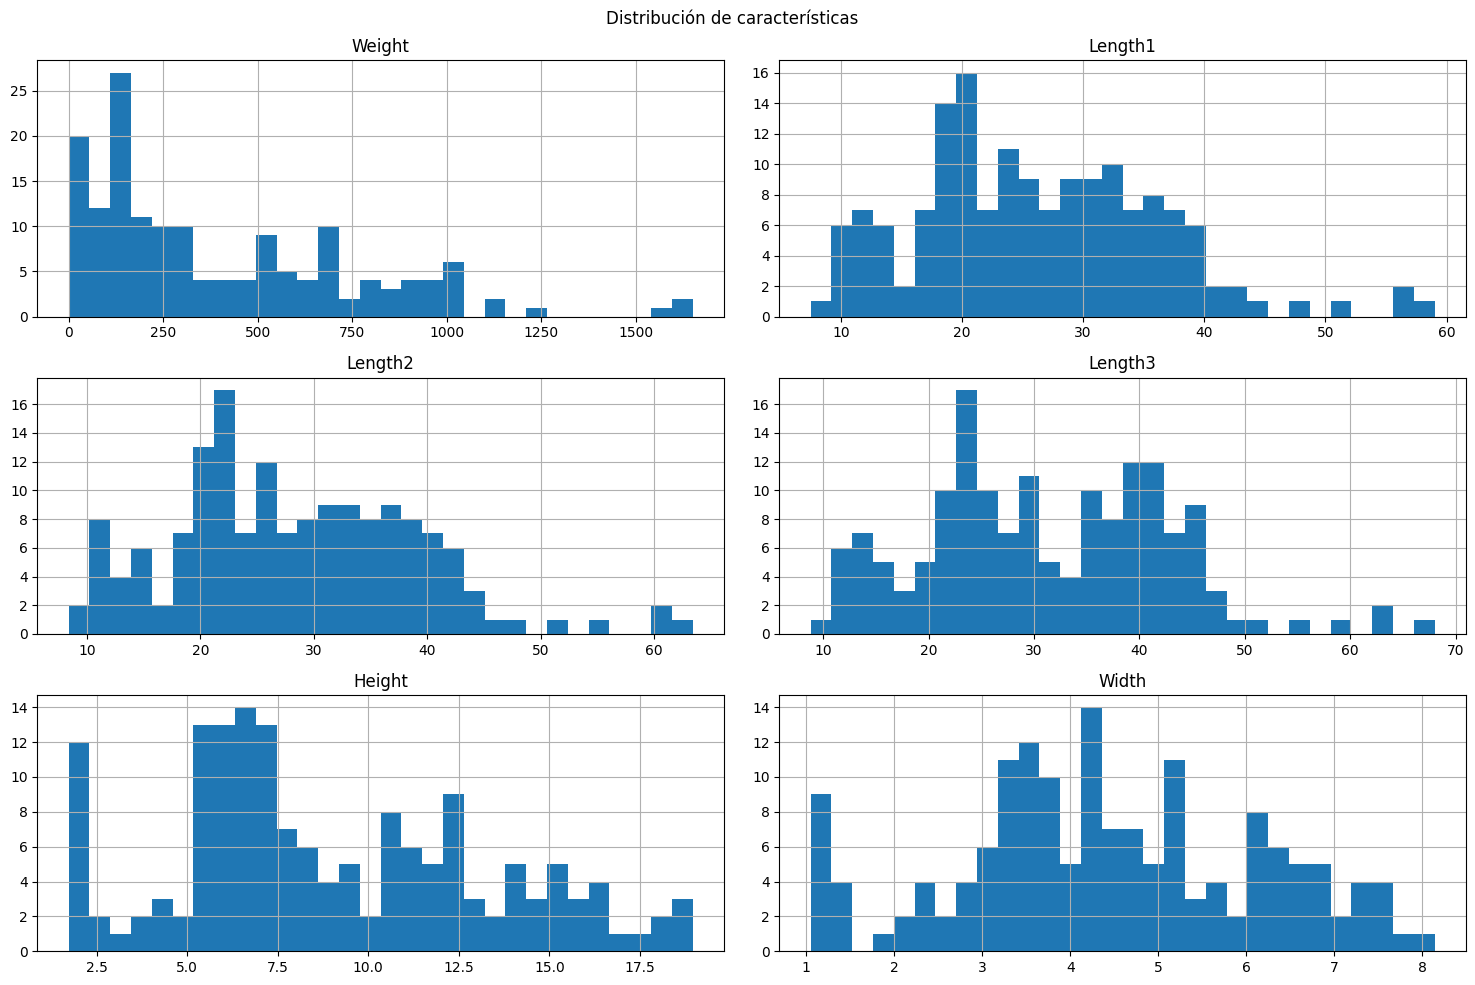


**** CORRELACIONES ****
Correlaciones respecto a Weight:
Weight     1.000000
Length3    0.923044
Length2    0.918618
Length1    0.915712
Width      0.886507
Height     0.724345
Name: Weight, dtype: float64


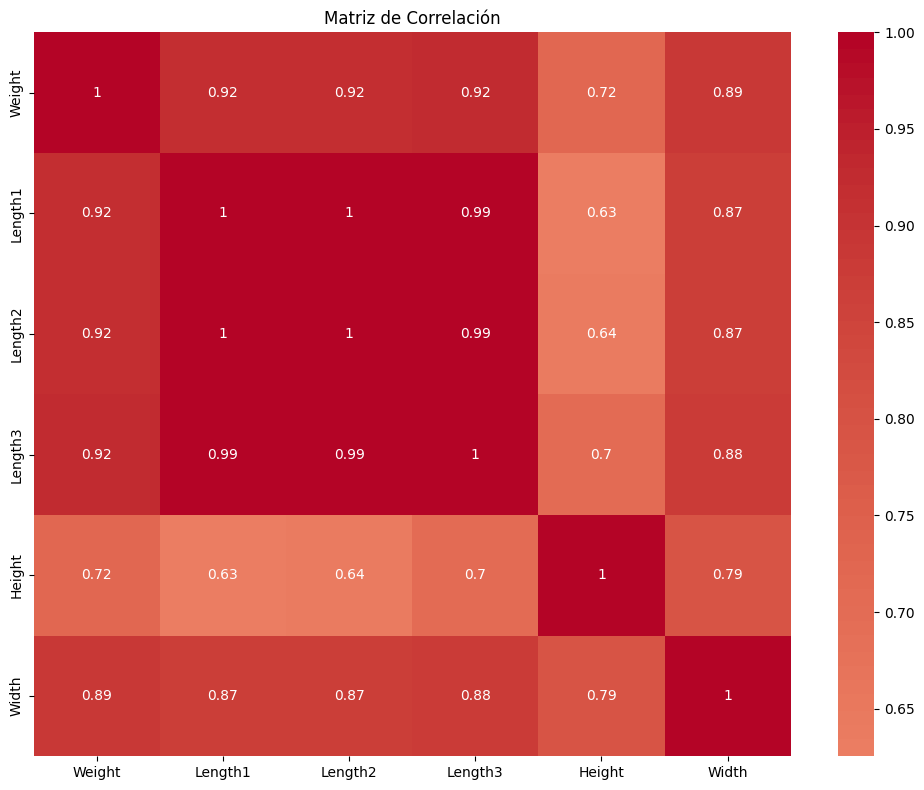

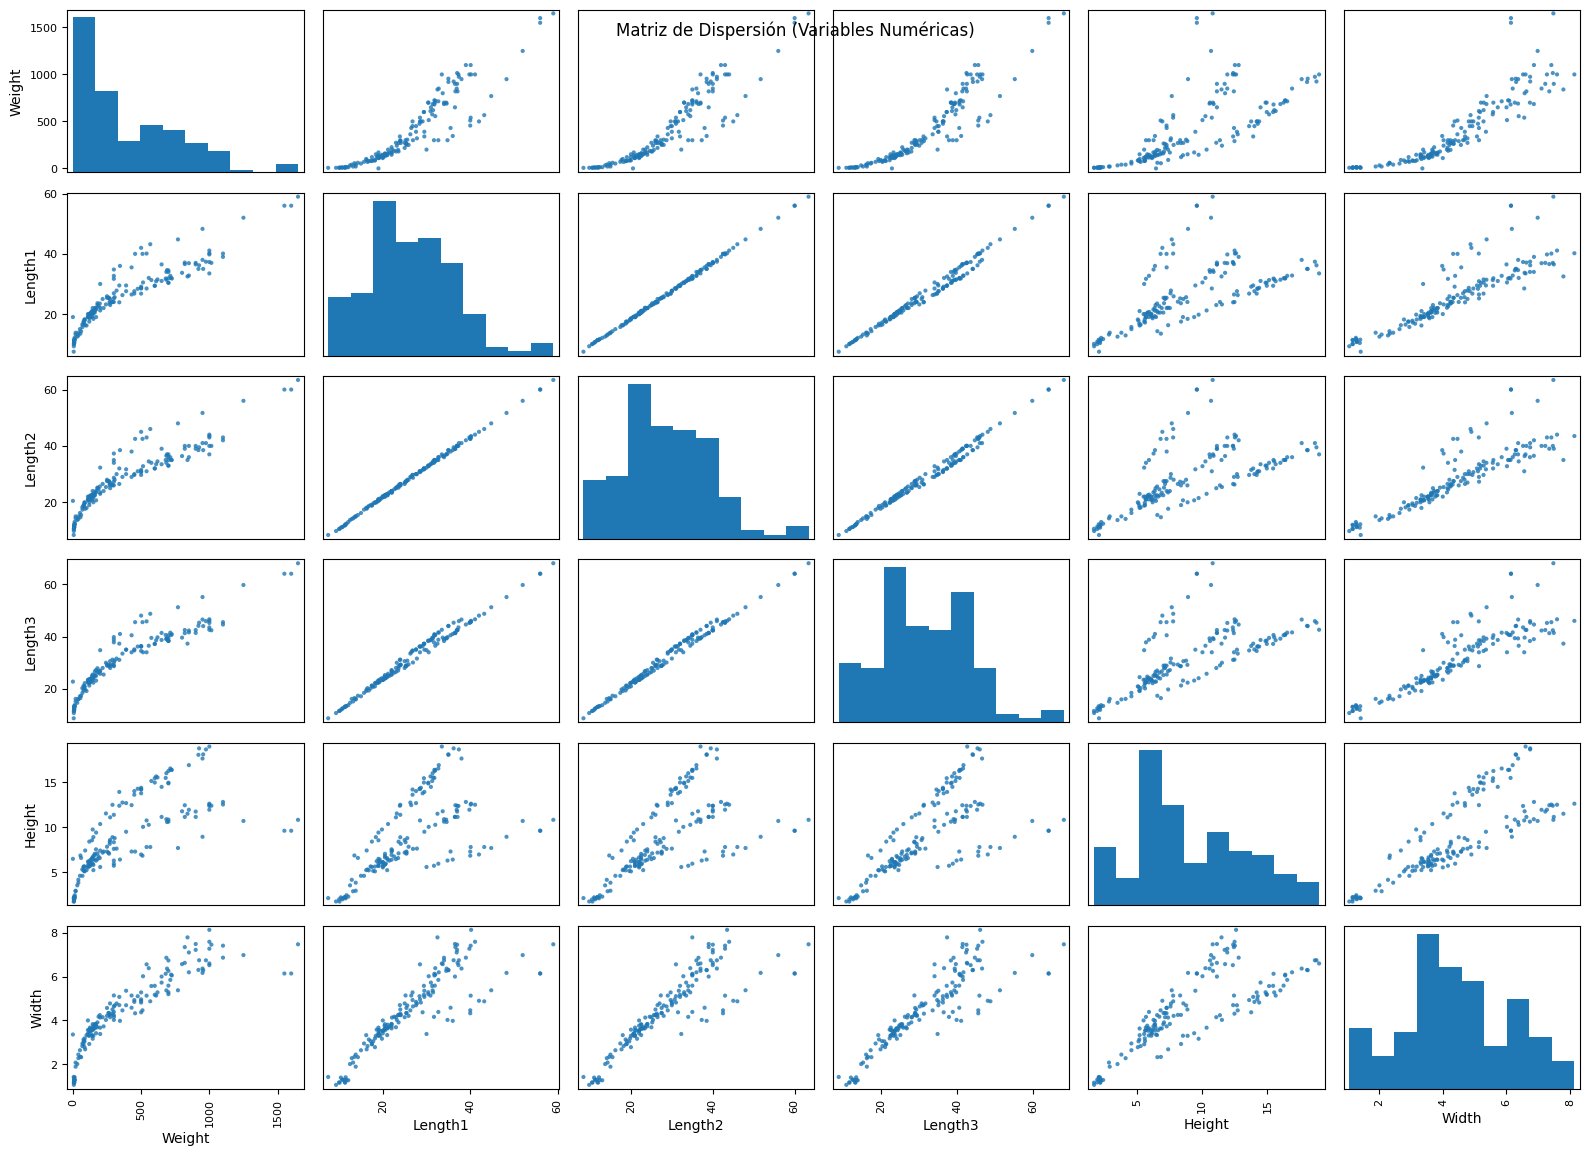


**** PREPARACIÓN DE DATOS ****
valores nulos por columna:
Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64
Tamaño conjunto entrenamiento: 127
Tamaño conjunto prueba: 32

Características de entrenamiento: (127, 6)
Variable objetivo entrenamiento: (127,)
Características de prueba: (32, 6)
Variable objetivo prueba: (32,)

**** CONSTRUCCIÓN DEL PIPELINE ****

**** ENTRENAMIENTO ****
1. entrenando regresión lineal
   RMSE regresión lineal: 117.43
   MAE regresión lineal: 77.03
2. entrenando árbol de decisión
   RMSE árbol de decisión: 98.71
   MAE árbol de decisión: 57.20
3. entrenando random forest
   RMSE random forest: 79.12
   MAE random forest: 46.60

**** CROSS VALIDATION ****
Regresión Lineal - CV (k=5):
  RMSE: [153.74375946  60.03363968  82.66871189 136.07128934  78.03270935]
  Media: 102.11
  Desviación estándar: 36.19

Árbol de Decisión - CV (k=5):
  RMSE: [ 97.61002668 100.0673062   66.16497563 109.06828137 112.81251349]
  

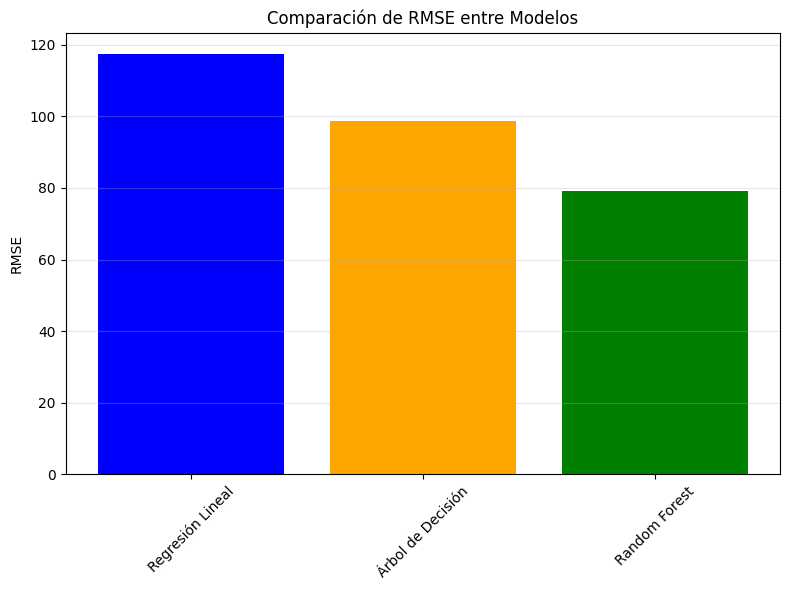


**** PREDICCIONES DE EJEMPLO ****
     Real  Predicho  Diferencia
0   850.0    773.18       76.82
1   200.0    186.87       13.13
2    12.2     10.51        1.69
3   556.0    653.99      -97.99
4   130.0    110.90       19.10
5   130.0    148.15      -18.15
6   390.0    407.12      -17.12
7  1600.0   1374.40      225.60
8    12.2     11.81        0.39
9   145.0    172.80      -27.80

**** ANÁLISIS FINAL ****
El mejor modelo es: Random Forest con RMSE = 79.12
Esto significa que en promedio, las predicciones del modelo
se desvían aproximadamente 79.12 gramos del peso real.

Comparación de todos los modelos:
  Regresión Lineal: RMSE = 117.43
  Árbol de Decisión: RMSE = 98.71
  Random Forest: RMSE = 79.12


In [5]:
# (práctica 2 - ejercicio 4) Regresión - dataset Fish
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

# [ACLARACIÓN]:
# para este ejercicio se tomo el dataset Fish.csv que incluye información
# sobre peces de diferentes mercados y la idea es intentar predecir el
# peso de un pez en gramos basado en sus características. Debajo se encuentra
# la descripción del dataset tomado de la página:

# [Fish Market Dataset]
# This dataset includes data on the common fish species in fish market sales.
# Attributes include weight, length, height and width of fish used to predict
# fish weight based on these physical characteristics.
# [Dataset Source]: Fish Market Dataset
# [Labels]: Continuous values representing the weight of the fish (in grams).
# [Size]: 159 samples each with 7 attributes.
# [Data]: Numerical data

def load_fish_data():
    return pd.read_csv(Path("C:\Users\facun\IA-UNRC-2025\tp\Fish.csv"))

# cargo datos y analizo algunas filas
fish = load_fish_data()
print("**** primeras filas del dataset: ****")
print(fish.head())
print("\n**** información del dataset: ****")
print(fish.info())
print("\n**** estadísticas descriptivas: ****")
print(fish.describe())

# características/features de los peces:
# Species (Especie)                -> única var categórica
# Weight  (Peso en gramos)         -> variable objetivo
# Length1
# Length2
# Length3
# Height  (Altura del pez)
# Width   (Ancho del pez)

# Length1, Length2 y Length3 son diferentes medidas del pez pero no se especifica cuales exactamente

# variable objetivo a predecir: Weight (peso del pez en gramos)

# [análisis de los datos y gráficos para explorar]
print("\n**** ANÁLISIS EXPLORATORIO ****")

# histogramas
fish.hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribución de características")
plt.tight_layout()
plt.show()

# búsqueda de correlaciones
print("\n**** CORRELACIONES ****")

# matriz de correlación
corr_matrix = fish.corr(numeric_only=True)
print("Correlaciones respecto a Weight:")
print(corr_matrix["Weight"].sort_values(ascending=False))

# heatmap de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

# matriz de dispersión para ver relaciones entre cada par de variables (solo las numéricas)
attributes = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]
scatter_matrix(fish[attributes], figsize=(16, 12), alpha=0.8)
plt.suptitle("Matriz de Dispersión (Variables Numéricas)", y=0.95)
plt.tight_layout()
plt.show()

# preparación de los datos
print("\n**** PREPARACIÓN DE DATOS ****")

# verificar que no haya valores nulos
print("valores nulos por columna:")
print(fish.isnull().sum()) # no hay datos null

# separo los datos para entrenamiento y validación (80%-20%):
# uso estratificación dividiendo en estratos por la
# característica 'Species' para evitar el sesgo por muestreo
# dado que no hay tantos datos (hay 159 en total)
strat_train_set, strat_test_set = train_test_split(
    fish, test_size=0.2, stratify=fish["Species"], random_state=42
)

print(f"Tamaño conjunto entrenamiento: {len(strat_train_set)}") # 80%
print(f"Tamaño conjunto prueba: {len(strat_test_set)}")         # 20%

# preparar características y variable objetivo:
# primero hay que excluir 'Weight' de las características
# ya que es la variable objetivo
X_train = strat_train_set.drop("Weight", axis=1)
y_train = strat_train_set["Weight"].copy()

X_test = strat_test_set.drop("Weight", axis=1)
y_test = strat_test_set["Weight"].copy()

# [*********************BORRAR???????????????????????********]:
# chequeamos la cantidad de datos que hay para entrenamiento
# y para validación y cuantas características tienen cada dato
# [es para chequear que sacamos Weight y la movimos a var objetivo]
print(f"\nCaracterísticas de entrenamiento: {X_train.shape}")
print(f"Variable objetivo entrenamiento: {y_train.shape}")
print(f"Características de prueba: {X_test.shape}")
print(f"Variable objetivo prueba: {y_test.shape}")

# pipeline de preprocesamiento
print("\n**** CONSTRUCCIÓN DEL PIPELINE ****")

# definimos que características son numéricas y cuales categóricas
# no incluimos 'Weight' ya que es la var objetivo
num_attribs = ["Length1", "Length2", "Length3", "Height", "Width"]
cat_attribs = ["Species"]

# pipeline para las características numéricas:
# 'SimpleImputer' permite rellenar datos faltates con la media de la columna y
# aunque en este caso no faltan datos se deja como una medida de seguridad por
# si en el futuro se añaden mas datos o por cualquier otro motivo.
# Luego 'StandardScaler' sirve para normalizar los datos usando estandarización.
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

# pipeline para características categóricas:
# acá nuevamente usamos 'SimpleImputer' para rellenar datos faltantes y
# 'OneHotEncoder' para codificar las variables dandoles una
# representación binaria única a cada una.
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# combinamos los pipelines
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

# entrenamiento y evaluación de varios modelos para comparar:
print("\n**** ENTRENAMIENTO ****")

# [Modelo 1]: regresión lineal
print("1. entrenando regresión lineal")
lin_reg = Pipeline([
    ('preprocessing', preprocessing),
    ('linear_regression', LinearRegression())
])

lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin)) # métrica RMSE
mae_lin = mean_absolute_error(y_test, y_pred_lin)          # métrica MAE

print(f"   RMSE regresión lineal: {rmse_lin:.2f}")
print(f"   MAE regresión lineal: {mae_lin:.2f}")

# [Modelo 2]: árbol de decisión (DT)
print("2. entrenando árbol de decisión")
tree_reg = Pipeline([
    ('preprocessing', preprocessing),
    ('decision_tree', DecisionTreeRegressor(random_state=42))
])

tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)

print(f"   RMSE árbol de decisión: {rmse_tree:.2f}")
print(f"   MAE árbol de decisión: {mae_tree:.2f}")

# [Modelo 3]: random forest
print("3. entrenando random forest")
forest_reg = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(n_estimators=100, random_state=42))
])

forest_reg.fit(X_train, y_train)
y_pred_forest = forest_reg.predict(X_test)

rmse_forest = np.sqrt(mean_squared_error(y_test, y_pred_forest))
mae_forest = mean_absolute_error(y_test, y_pred_forest)

print(f"   RMSE random forest: {rmse_forest:.2f}")
print(f"   MAE random forest: {mae_forest:.2f}")

# cross-validation:
# dado que tenemos pocos datos (159) usar cross-validation es útil.
# usamos 5 folds (cv=5)
print("\n**** CROSS VALIDATION ****")

# cross-validation para regresión lineal
lin_scores = cross_val_score(lin_reg, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
lin_rmse_scores = np.sqrt(-lin_scores)

print(f"Regresión Lineal - CV (k=5):")
print(f"  RMSE: {lin_rmse_scores}")
print(f"  Media: {lin_rmse_scores.mean():.2f}")
print(f"  Desviación estándar: {lin_rmse_scores.std():.2f}")

# cross-validation para árbol de decisión
tree_scores = cross_val_score(tree_reg, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
tree_rmse_scores = np.sqrt(-tree_scores)

print(f"\nÁrbol de Decisión - CV (k=5):")
print(f"  RMSE: {tree_rmse_scores}")
print(f"  Media: {tree_rmse_scores.mean():.2f}")
print(f"  Desviación estándar: {tree_rmse_scores.std():.2f}")

# cross-validation para random forest
forest_scores = cross_val_score(forest_reg, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
forest_rmse_scores = np.sqrt(-forest_scores)

print(f"\nRandom Forest - CV (k=5):")
print(f"  RMSE: {forest_rmse_scores}")
print(f"  Media: {forest_rmse_scores.mean():.2f}")
print(f"  Desviación estándar: {forest_rmse_scores.std():.2f}")

# comparación de los modelos
print("\n**** COMPARACIÓN DE MODELOS ****")
model_comparison = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
    'RMSE': [rmse_lin, rmse_tree, rmse_forest],
    'MAE': [mae_lin, mae_tree, mae_forest]
})
print(model_comparison)

# gráfico de comparación de modelos para el RMSE
plt.figure(figsize=(8, 6))
plt.bar(model_comparison['Modelo'], model_comparison['RMSE'], color=['blue', 'orange', 'green'])
plt.xticks(rotation=45)
plt.ylabel('RMSE')
plt.title('Comparación de RMSE entre Modelos')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# BORRAR???????????************************************************
# finamente algunas predicciones de ejemplo
print("\n**** PREDICCIONES DE EJEMPLO ****")
sample_predictions = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicho': y_pred_forest[:10].round(2),
    'Diferencia': (y_test.values[:10] - y_pred_forest[:10]).round(2)
})
print(sample_predictions)

print("\n**** ANÁLISIS FINAL ****")

# encontrar el mejor modelo basado en RMSE
modelos = {
    'Regresión Lineal': rmse_lin,
    'Árbol de Decisión': rmse_tree,
    'Random Forest': rmse_forest
}

mejor_modelo = min(modelos, key=modelos.get) # el que tenga menor error
mejor_rmse = modelos[mejor_modelo]

print(f"El mejor modelo es: {mejor_modelo} con RMSE = {mejor_rmse:.2f}")
print(f"Esto significa que en promedio, las predicciones del modelo")
print(f"se desvían aproximadamente {mejor_rmse:.2f} gramos del peso real.")

print("\nComparación de todos los modelos:")
for modelo, rmse in modelos.items():
    print(f"  {modelo}: RMSE = {rmse:.2f}")
